# 01 - Tiền xử lý & Chọn đặc trưng MI (ĐA LỚP / Multiclass)

**Bám sát bài báo gốc (Section 3):** phân loại **đa lớp** theo cột `type` (10 lớp tấn công),
mã hóa **One-hot** cho categorical, chuẩn hóa Min-Max, chọn **top-30** đặc trưng bằng Mutual Information.

> **Quy ước tiền xử lý (ghi rõ trong báo cáo):** Loại bỏ các cột *định danh luồng* (`src_ip`, `dst_ip`)
> và *free-text* siêu cao chiều (`dns_query`, `http_uri`, `http_user_agent`) để tránh rò rỉ định danh
> (identity leakage) và bùng nổ số chiều khi One-hot. One-hot được áp dụng cho các categorical còn lại.

**Chống rò rỉ dữ liệu:** split TRƯỚC, chỉ fit encoder/MI/scaler trên tập TRAIN.
Artifacts lưu ở `data/colab_processed/` sẽ được các notebook 02-10 dùng lại (nguồn dữ liệu duy nhất).

In [1]:
# === Thiết lập môi trường ỔN ĐỊNH (tránh lỗi Drive 'Transport endpoint is not connected') ===
# Làm việc trên Ổ CỨNG LOCAL /content (nhanh + ổn định); chỉ ĐỒNG BỘ kết quả về Drive ở cuối.
import os, time, shutil
from contextlib import contextmanager

DRIVE = '/content/drive/MyDrive/Nhom28_CyberDetect_MLP_Final'
PROJECT_PATH = '/content/cdmlp'
NEED_RAW = False   # True chi voi notebook 08 (cross-dataset can data/raw)
ON_COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    ON_COLAB = True
except Exception:
    here = os.getcwd()
    while here != os.path.dirname(here) and not os.path.isdir(os.path.join(here, 'notebooks')):
        here = os.path.dirname(here)
    DRIVE = here; PROJECT_PATH = here

def _pull(rel):
    s = os.path.join(DRIVE, rel); d = os.path.join(PROJECT_PATH, rel)
    if os.path.isdir(s): shutil.copytree(s, d, dirs_exist_ok=True)
    elif os.path.isfile(s):
        os.makedirs(os.path.dirname(d), exist_ok=True); shutil.copy2(s, d)

if ON_COLAB:
    os.makedirs(PROJECT_PATH, exist_ok=True)
    for rel in ['scripts','src','models','results','data/colab_processed','data/ton_iot.csv']:
        try: _pull(rel)
        except Exception as e: print('  (bo qua)', rel, e)
    if NEED_RAW:
        print('  Dang keo data/raw (~550MB, 1-3 phut)...')
        try: _pull('data/raw')
        except Exception as e: print('  (bo qua) data/raw', e)

os.makedirs(PROJECT_PATH, exist_ok=True); os.chdir(PROJECT_PATH)
try:
    get_ipython().run_line_magic('cd', PROJECT_PATH)  # dam bao '!python ...' cung chay o local dir
except Exception:
    pass
for d in ('data/colab_processed','results','results/xai','models'):
    os.makedirs(d, exist_ok=True)
print('PROJECT_PATH (local) =', PROJECT_PATH, '| ON_COLAB =', ON_COLAB)

def find_data_csv():
    for c in ['data/ton_iot.csv','data/raw/ton_iot.csv','ton_iot.csv']:
        if os.path.exists(c): return c
    raise FileNotFoundError('Khong tim thay ton_iot.csv (Drive: data/ton_iot.csv).')

@contextmanager
def step(name):
    t0=time.time(); print(f'\n[START] {name}', flush=True)
    try: yield
    finally: print(f'[DONE] {name} - {time.time()-t0:.1f}s', flush=True)

def sync_to_drive():
    if not ON_COLAB:
        print('[local] bo qua sync Drive'); return
    for rel in ['data/colab_processed','models','results']:
        s = os.path.join(PROJECT_PATH, rel)
        if os.path.exists(s): shutil.copytree(s, os.path.join(DRIVE, rel), dirs_exist_ok=True)
    print('[OK] Da dong bo ket qua ve Drive:', DRIVE)


Mounted at /content/drive
/content
PROJECT_PATH (local) = /content/cdmlp | ON_COLAB = True


In [2]:
!pip -q install pandas numpy scikit-learn pyarrow matplotlib seaborn joblib


[START] Load CSV
[DONE] Load CSV - 1.3s
[INFO] Raw shape: (211043, 44)
[INFO] So lop = 10: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64

[START] Stratified 80/20 split (TRUOC khi fit gi het)
[DONE] Stratified 80/20 split (TRUOC khi fit gi het) - 0.2s
[INFO] Train: (168834, 37) | Test: (42209, 37)
[INFO] 16 numeric + 21 categorical (one-hot)

[START] Fit One-hot/imputer tren TRAIN, transform test
[DONE] Fit One-hot/imputer tren TRAIN, transform test - 1.9s
[INFO] So dac trung sau One-hot: 124

[START] Mutual Information top-30 (tren train, co subsample)
[DONE] Mutual Information top-30 (tren train, co subsample) - 24.7s

[START] MinMax scale (fit tren train)
[DONE] MinMax scale (fit tren train) - 0.2s

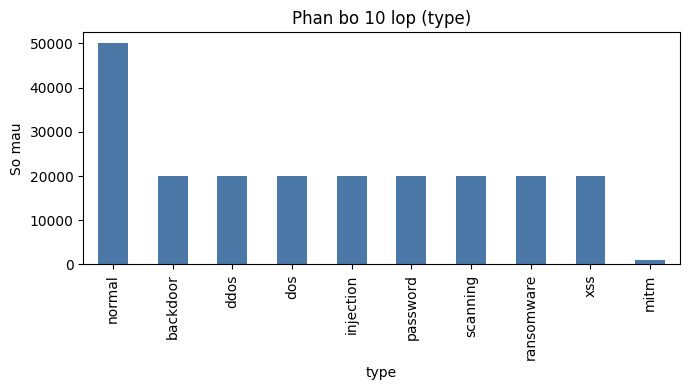

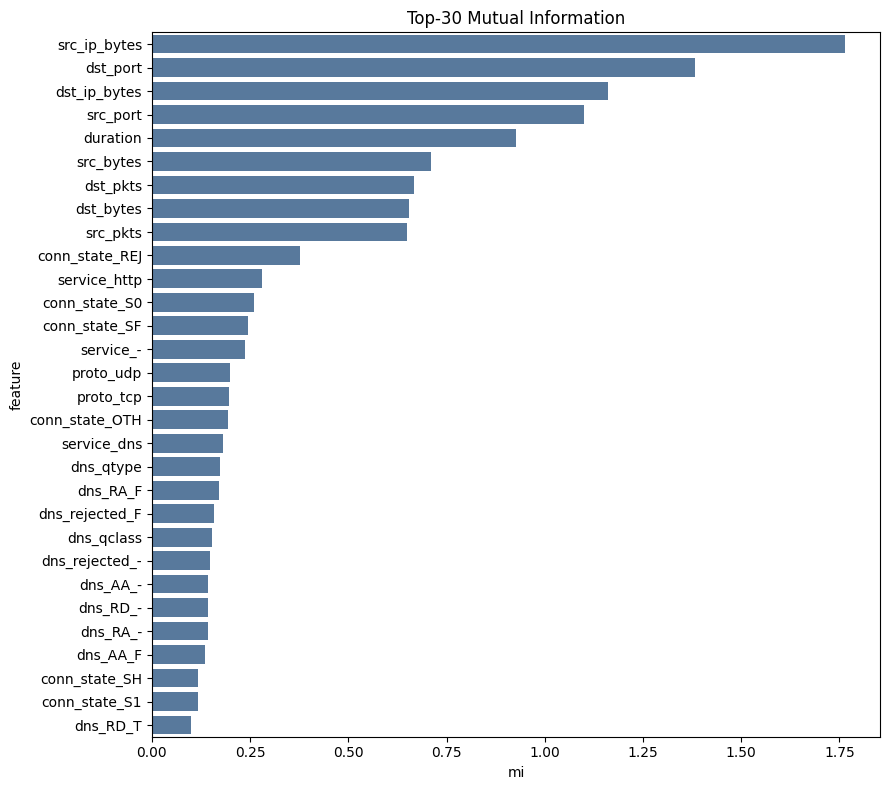

[OK] Da luu artifacts da lop vao data/colab_processed | n_classes = 10


In [3]:
import os, json, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif

SEED = 42; TOP_K = 30
LABEL_COL = 'type'          # <-- DA LOP (paper dung phan loai da lop)
# Cột bị loại: nhãn + định danh luồng + free-text cao chiều
DROP_ALWAYS = ['label', 'type', 'attack_type', 'category', 'ts',
               'src_ip', 'dst_ip', 'dns_query', 'http_uri', 'http_user_agent']
MI_SAMPLE = 40000           # subsample de tinh MI cho nhanh (chi tren train)

OUT = 'data/colab_processed'; RESULTS = 'results'; MODELS = 'models'
for d in (OUT, RESULTS, MODELS): os.makedirs(d, exist_ok=True)

def make_ohe():
    try: return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError: return OneHotEncoder(handle_unknown='ignore', sparse=False)

with step('Load CSV'):
    df = pd.read_csv(find_data_csv(), low_memory=False)
print('[INFO] Raw shape:', df.shape)
assert LABEL_COL in df.columns, f'Khong co cot nhan {LABEL_COL}'

y_raw = df[LABEL_COL].astype(str)
le = LabelEncoder(); y = le.fit_transform(y_raw)
class_names = [str(c) for c in le.classes_]
n_classes = len(class_names)
print(f'[INFO] So lop = {n_classes}: {class_names}')
print(df[LABEL_COL].value_counts())

X_raw = df.drop(columns=[c for c in DROP_ALWAYS if c in df.columns], errors='ignore')

with step('Stratified 80/20 split (TRUOC khi fit gi het)'):
    Xtr_raw, Xte_raw, ytr, yte = train_test_split(
        X_raw, y, test_size=0.2, stratify=y, random_state=SEED)
print('[INFO] Train:', Xtr_raw.shape, '| Test:', Xte_raw.shape)

cat_cols = Xtr_raw.select_dtypes(include=['object','category','bool']).columns.tolist()
num_cols = [c for c in Xtr_raw.columns if c not in cat_cols]
print(f'[INFO] {len(num_cols)} numeric + {len(cat_cols)} categorical (one-hot)')

pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='mean'))]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', make_ohe())]), cat_cols),
], remainder='drop', verbose_feature_names_out=False)

with step('Fit One-hot/imputer tren TRAIN, transform test'):
    Xtr_all = np.nan_to_num(pre.fit_transform(Xtr_raw).astype(np.float32))
    Xte_all = np.nan_to_num(pre.transform(Xte_raw).astype(np.float32))
feat_names = list(pre.get_feature_names_out())
print('[INFO] So dac trung sau One-hot:', Xtr_all.shape[1])

with step('Mutual Information top-30 (tren train, co subsample)'):
    if len(ytr) > MI_SAMPLE:
        idx = np.random.RandomState(SEED).choice(len(ytr), MI_SAMPLE, replace=False)
        mi = mutual_info_classif(Xtr_all[idx], ytr[idx], random_state=SEED, discrete_features=False)
    else:
        mi = mutual_info_classif(Xtr_all, ytr, random_state=SEED, discrete_features=False)
top_idx = np.argsort(mi)[::-1][:TOP_K]
top_features = [feat_names[i] for i in top_idx]

with step('MinMax scale (fit tren train)'):
    scaler_top = MinMaxScaler(); Xtr_top = scaler_top.fit_transform(Xtr_all[:, top_idx]); Xte_top = scaler_top.transform(Xte_all[:, top_idx])
    scaler_all = MinMaxScaler(); Xtr_all_s = scaler_all.fit_transform(Xtr_all); Xte_all_s = scaler_all.transform(Xte_all)

with step('Luu artifacts (nguon du lieu duy nhat cho NB 02-10)'):
    pd.DataFrame(Xtr_top, columns=top_features).to_parquet(f'{OUT}/X_train_top30.parquet', index=False)
    pd.DataFrame(Xte_top, columns=top_features).to_parquet(f'{OUT}/X_test_top30.parquet', index=False)
    pd.DataFrame(Xtr_all_s, columns=feat_names).to_parquet(f'{OUT}/X_train_all.parquet', index=False)
    pd.DataFrame(Xte_all_s, columns=feat_names).to_parquet(f'{OUT}/X_test_all.parquet', index=False)
    pd.DataFrame({'label': ytr}).to_parquet(f'{OUT}/y_train.parquet', index=False)
    pd.DataFrame({'label': yte}).to_parquet(f'{OUT}/y_test.parquet', index=False)
    # Lưu pipeline đã fit + scaler + top_idx để script concept-drift tiền xử lý dữ liệu RAW nhất quán
    joblib.dump({'preprocessor': pre, 'scaler_top': scaler_top, 'top_idx': top_idx,
                 'top_features': top_features, 'label_encoder': le,
                 'drop_always': DROP_ALWAYS, 'label_col': LABEL_COL},
                f'{MODELS}/colab_preprocessor.joblib')

meta = {'task': 'multiclass', 'label_col': LABEL_COL, 'seed': SEED, 'top_k': TOP_K,
        'n_classes': n_classes, 'class_names': class_names, 'top_features': top_features,
        'n_all_features': int(Xtr_all_s.shape[1]), 'n_train': int(len(ytr)), 'n_test': int(len(yte)),
        'dropped_columns': DROP_ALWAYS,
        'protocol': 'Multiclass paper-aligned: split first; fit One-hot/MI/scaler on TRAIN only.'}
json.dump(meta, open(f'{MODELS}/colab_preprocessing_metadata.json','w',encoding='utf-8'), indent=2)
pd.DataFrame({'feature': feat_names, 'mi_score': mi}).sort_values('mi_score', ascending=False).to_csv(f'{RESULTS}/colab_mi_scores.csv', index=False)

# Biểu đồ phân bộ lớp + top-30 MI
plt.figure(figsize=(7,4)); pd.Series(y_raw).value_counts().plot(kind='bar', color='#4c78a8')
plt.title('Phan bo 10 lop (type)'); plt.ylabel('So mau'); plt.tight_layout()
plt.savefig(f'{RESULTS}/fig_colab_label_distribution.png', dpi=150); plt.show()
mi_top = pd.DataFrame({'feature': top_features, 'mi': mi[top_idx]})
plt.figure(figsize=(9,8)); sns.barplot(data=mi_top, y='feature', x='mi', color='#4c78a8')
plt.title('Top-30 Mutual Information'); plt.tight_layout()
plt.savefig(f'{RESULTS}/fig_colab_mi_top30.png', dpi=150); plt.show()
print('[OK] Da luu artifacts da lop vao', OUT, '| n_classes =', n_classes)

In [5]:
# === ĐỒNG BỘ KẾT QUẢ VỀ GOOGLE DRIVE (chạy cuối cùng, sau khi các cell trên xong) ===
sync_to_drive()


[OK] Da dong bo ket qua ve Drive: /content/drive/MyDrive/Nhom28_CyberDetect_MLP_Final
